# Projet de classification d'images : MLP et CNN (CIFAR-10)

> Notebook pensé pour **Google Colab** avec téléchargement des données depuis le site officiel de Toronto.

## Objectifs
- Télécharger et préparer CIFAR-10 depuis la source officielle.
- Entraîner un modèle **MLP** de référence.
- Entraîner un modèle **CNN** plus performant.
- Comparer les performances et analyser les résultats.

In [1]:
# [Colab] Vérification de l'environnement d'exécution
import platform
import sys

print('Python :', sys.version)
print('Plateforme :', platform.platform())

try:
    import tensorflow as tf
    print('TensorFlow :', tf.__version__)
    print('GPU disponible :', tf.config.list_physical_devices('GPU'))
except Exception as exc:
    print('TensorFlow non disponible pour le moment :', exc)

Python : 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
Plateforme : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.19.1
GPU disponible : []


In [ ]:
# [Colab] Installation optionnelle (à décommenter si nécessaire)
# %pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [2]:
# Imports
from __future__ import annotations

from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Diagnostic environnement : Colab ou local
def detect_runtime() -> str:
    """Retourne le type d'environnement d'exécution du notebook."""
    return 'Colab' if Path('/content').exists() else 'Local'


RUNTIME_MODE = detect_runtime()
print('Mode d\'exécution :', RUNTIME_MODE)
print('Répertoire courant :', Path.cwd())

Mode d'exécution : Local
Répertoire courant : /home/coule/Desktop/Documents/projets/neuralzoo/notebooks


## 1) Téléchargement CIFAR-10 depuis la source officielle
Source: https://www.cs.toronto.edu/~kriz/cifar.html

In [4]:
# Téléchargement + extraction de CIFAR-10 (format Python)
def resolve_data_root() -> Path:
    """Choisit un dossier data compatible avec Colab ou une exécution locale."""
    # Si l'environnement Colab est détecté
    if Path('/content').exists():
        return Path('/content/data')

    # Sinon, on privilégie le dossier data du projet en local
    cwd = Path.cwd()
    if (cwd / 'data').exists():
        return cwd / 'data'
    if (cwd.parent / 'data').exists():
        return cwd.parent / 'data'

    # Fallback local si rien n'est trouvé
    return cwd / 'data'


DATA_ROOT = resolve_data_root()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print('DATA_ROOT utilisé :', DATA_ROOT.resolve())

CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
ARCHIVE_PATH = DATA_ROOT / 'cifar-10-python.tar.gz'
EXTRACT_DIR = DATA_ROOT / 'cifar-10-batches-py'

if not ARCHIVE_PATH.exists():
    print('Téléchargement de CIFAR-10...')
    urllib.request.urlretrieve(CIFAR_URL, ARCHIVE_PATH)
else:
    print('Archive déjà présente:', ARCHIVE_PATH)

if not EXTRACT_DIR.exists():
    print('Extraction de l\'archive...')
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(path=DATA_ROOT)
else:
    print('Dossier extrait déjà présent:', EXTRACT_DIR)

print('Prêt:', EXTRACT_DIR)

DATA_ROOT utilisé : /home/coule/Desktop/Documents/projets/neuralzoo/data
Archive déjà présente: /home/coule/Desktop/Documents/projets/neuralzoo/data/cifar-10-python.tar.gz
Dossier extrait déjà présent: /home/coule/Desktop/Documents/projets/neuralzoo/data/cifar-10-batches-py
Prêt: /home/coule/Desktop/Documents/projets/neuralzoo/data/cifar-10-batches-py


 ## Composition du dataset
- shape des fichiers
- liste des catégories

In [5]:
# Fonctions utilitaires de chargement CIFAR-10
def load_cifar_batch(batch_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Charge un batch CIFAR-10 (pickle) et retourne images + labels."""
    with batch_path.open('rb') as file:
        batch = pickle.load(file, encoding='bytes')
    images = batch[b'data']
    labels = np.array(batch[b'labels'], dtype=np.int64)
    return images, labels


def load_cifar10_from_toronto(extract_dir: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[str]]:
    """Charge l'ensemble CIFAR-10 à partir des fichiers téléchargés depuis Toronto."""
    train_images_list: list[np.ndarray] = []
    train_labels_list: list[np.ndarray] = []

    for idx in range(1, 6):
        x_batch, y_batch = load_cifar_batch(extract_dir / f'data_batch_{idx}')
        train_images_list.append(x_batch)
        train_labels_list.append(y_batch)

    x_train = np.vstack(train_images_list)
    y_train = np.concatenate(train_labels_list)

    x_test, y_test = load_cifar_batch(extract_dir / 'test_batch')

    with (extract_dir / 'batches.meta').open('rb') as file:
        meta = pickle.load(file, encoding='bytes')
    class_names = [name.decode('utf-8') for name in meta[b'label_names']]

    return x_train, y_train, x_test, y_test, class_names

In [ ]:
# Inspection du dataset: fichiers + shapes + catégories
dataset_files = sorted(EXTRACT_DIR.glob('*'))
print('Fichiers dans', EXTRACT_DIR)
for file_path in dataset_files:
    print('-', file_path.name)

print('\nShapes des batches:')
for batch_name in [f'data_batch_{i}' for i in range(1, 6)] + ['test_batch']:
    x_batch, y_batch = load_cifar_batch(EXTRACT_DIR / batch_name)
    print(f'- {batch_name}: X={x_batch.shape}, y={y_batch.shape}')

with (EXTRACT_DIR / 'batches.meta').open('rb') as file:
    meta = pickle.load(file, encoding='bytes')
class_names_all = [name.decode('utf-8') for name in meta[b'label_names']]

print('\nCatégories CIFAR-10:')
for idx, class_name in enumerate(class_names_all):
    print(f'{idx}: {class_name}')

In [ ]:
# Chargement, filtrage classes animales, puis remise en forme
x_train_flat, y_train, x_test_flat, y_test, class_names_all = load_cifar10_from_toronto(EXTRACT_DIR)

# On ne garde que les classes animales de CIFAR-10
animal_classes = ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']
animal_class_to_original_idx = {name: class_names_all.index(name) for name in animal_classes}
selected_original_indices = np.fromiter(
    (animal_class_to_original_idx[name] for name in animal_classes),
    dtype=np.int64,
    count=len(animal_classes),
)

# Cast explicite pour éviter les inférences de dtype ambiguës
y_train = y_train.astype(np.int64, copy=False)
y_test = y_test.astype(np.int64, copy=False)

train_mask = np.isin(y_train, selected_original_indices)
test_mask = np.isin(y_test, selected_original_indices)

x_train_flat = x_train_flat[train_mask]
y_train = y_train[train_mask]
x_test_flat = x_test_flat[test_mask]
y_test = y_test[test_mask]

# Remapping des labels vers [0..5] dans l'ordre animal_classes
original_to_new = {orig_idx: new_idx for new_idx, orig_idx in enumerate(selected_original_indices)}
y_train = np.array([original_to_new[int(lbl)] for lbl in y_train], dtype=np.int64)
y_test = np.array([original_to_new[int(lbl)] for lbl in y_test], dtype=np.int64)
class_names = animal_classes

# Format image: (N, 32, 32, 3)
x_train = x_train_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test_flat.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_test :', x_test.shape, 'y_test :', y_test.shape)
print('Classes conservées :', class_names)

/tmp/ipykernel_2140/2738286963.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(file, encoding='bytes')


x_train: (30000, 32, 32, 3) y_train: (30000,)
x_test : (6000, 32, 32, 3) y_test : (6000,)
Classes conservées : ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']


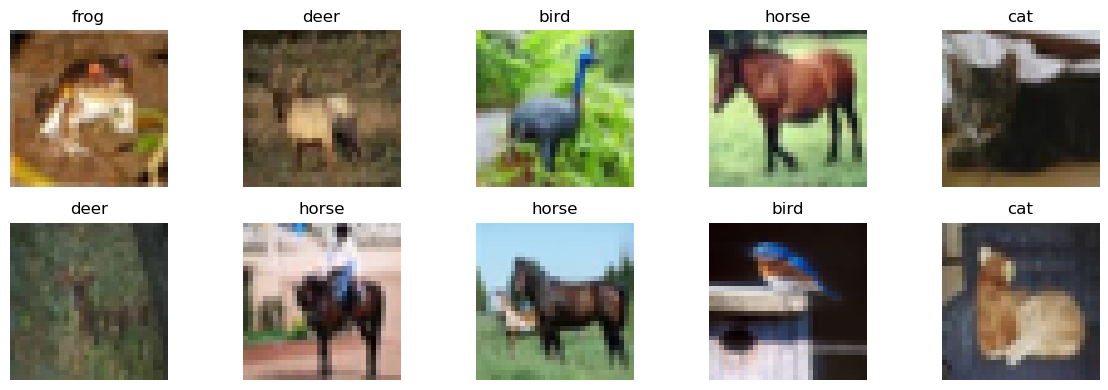

In [7]:
# Visualisation rapide de quelques images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Prétraitement pour MLP et CNN
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

num_classes = len(class_names)
y_train_cat = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=num_classes)

# Jeu de validation pour suivre l'apprentissage
x_train_norm, x_val, y_train_final, y_val = train_test_split(
    x_train_norm,
    y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
)

# Variante aplatie pour le MLP
x_train_mlp = x_train_final.reshape(x_train_final.shape[0], -1)
x_val_mlp = x_val.reshape(x_val.shape[0], -1)
x_test_mlp = x_test_norm.reshape(x_test_norm.shape[0], -1)

print('x_train_final :', x_train_final.shape)
print('x_val         :', x_val.shape)
print('x_test_norm   :', x_test_norm.shape)

x_train_final : (27000, 32, 32, 3)
x_val         : (3000, 32, 32, 3)
x_test_norm   : (6000, 32, 32, 3)


## 2) Modèle de base : MLP

In [9]:
# Définition et entraînement du MLP
mlp_model = keras.Sequential(
    [
        layers.Input(shape=(32 * 32 * 3,)),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ],
    name='mlp_cifar10',
)

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

mlp_history = mlp_model.fit(
    x_train_mlp,
    y_train_final,
    validation_data=(x_val_mlp, y_val),
    epochs=12,
    batch_size=128,
    verbose=1,
)

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.2521 - loss: 1.8167 - val_accuracy: 0.3420 - val_loss: 1.6090
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3196 - loss: 1.6447 - val_accuracy: 0.3730 - val_loss: 1.5478
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3422 - loss: 1.6002 - val_accuracy: 0.3823 - val_loss: 1.5498
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.3291 - loss: 1.6058 - val_accuracy: 0.3947 - val_loss: 1.5275
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.3554 - loss: 1.5661 - val_accuracy: 0.4087 - val_loss: 1.5247
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.3650 - loss: 1.5507 - val_accuracy: 0.3917 - val_loss: 1.4987
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.3642 - loss: 1.5585 - val_accuracy: 0.4000 - val_loss: 1.5000
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.3667 - loss: 1.5491 - val_

## 3) Modèle convolutionnel : CNN

In [ ]:
# Définition et entraînement du CNN
cnn_model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ],
    name='cnn_cifar10',
)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 197ms/step - accuracy: 0.3634 - loss: 1.5465 - val_accuracy: 0.4753 - val_loss: 1.3444
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.5060 - loss: 1.2714 - val_accuracy: 0.5723 - val_loss: 1.1193
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - accuracy: 0.5654 - loss: 1.1282 - val_accuracy: 0.6127 - val_loss: 1.0440
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 39s 184ms/step - accuracy: 0.6087 - loss: 1.0341 - val_accuracy: 0.6423 - val_loss: 0.9517
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 181ms/step - accuracy: 0.6360 - loss: 0.9607 - val_accuracy: 0.6703 - val_loss: 0.9027
Epoch 6/15
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.6655 - loss: 0.9056

In [ ]:
# Évaluation quantitative des modèles
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test_mlp, y_test_cat, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test_cat, verbose=0)

results_df = pd.DataFrame(
    [
        {'modele': 'MLP', 'test_loss': mlp_test_loss, 'test_accuracy': mlp_test_acc},
        {'modele': 'CNN', 'test_loss': cnn_test_loss, 'test_accuracy': cnn_test_acc},
    ]
)

print(results_df)

In [ ]:
# Courbes d'apprentissage
def plot_history(history: keras.callbacks.History, title_prefix: str) -> None:
    """Affiche les courbes de perte et d'accuracy pour un historique Keras."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{title_prefix} - Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title(f'{title_prefix} - Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(mlp_history, 'MLP')
plot_history(cnn_history, 'CNN')

In [ ]:
# Rapport de classification et matrice de confusion (CNN)
y_pred_cnn = np.argmax(cnn_model.predict(x_test_norm, verbose=0), axis=1)

print(classification_report(y_test, y_pred_cnn, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Matrice de confusion - CNN')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

## Cartouche final
- Projet: Classification d'images CIFAR-10 (MLP vs CNN).
- Exécution: compatible Google Colab (CPU/GPU).
- Source des données: https://www.cs.toronto.edu/~kriz/cifar.html
- Sorties attendues: métriques de test, courbes d'apprentissage, matrice de confusion.
- Piste d'amélioration: data augmentation, scheduler de learning rate, transfert d'apprentissage (ResNet/EfficientNet).